# 4. Beams, noise and contaminant deprojection

Real maps are smoothed by the instrument beam, contain noise, and are contaminated by foregrounds.
This notebook shows the three standard tools NaMaster provides, all available in GMaster:

1. **beam deconvolution**: pass the beam transfer function $b_\ell$ to the field;
2. **noise-bias-free cross-spectra**: correlate two maps with independent noise (data splits);
3. **template deprojection**: marginalise over a known contaminant spatial template, and correct
   the small bias this introduces (Elsner, Leistedt & Peiris 2017; Alonso et al. 2019).

In [1]:
import os
os.environ.setdefault("JAX_ENABLE_X64", "1")   # NaMaster-level double precision; set before importing JAX

import time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import jax
import gmaster as nmt

print("GMaster", nmt.__version__, "| JAX", jax.__version__, "| device:", jax.devices()[0].device_kind)

GMaster 1.0.0 | JAX 0.10.0 | device: NVIDIA RTX PRO 6000 Blackwell Workstation Edition


In [2]:
import camb

def camb_spectra(lmax, r=0.0):
    """Lensed CMB C_ell in muK^2 (TT, EE, BB, TE) for a Planck-2018-like cosmology, ell = 0..lmax."""
    pars = camb.set_params(H0=67.4, ombh2=0.0224, omch2=0.120, mnu=0.06, omk=0, tau=0.054,
                           As=2.1e-9, ns=0.965, r=r, lmax=lmax + 500, WantTensors=r > 0)
    res = camb.get_results(pars)
    cl = res.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True, lmax=lmax)["total"]
    return {k: cl[:, i] for i, k in enumerate(["TT", "EE", "BB", "TE"])}

nside = 256
lmax = 3 * nside - 1
ell = np.arange(lmax + 1)
cl_tt = camb_spectra(lmax)["TT"]

theta, phi = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
binary = (np.abs(90.0 - np.degrees(theta)) > 20.0).astype(float)
mask = np.asarray(nmt.mask_apodization(binary, 2.0, apotype="C1"))
bins = nmt.NmtBin.from_nside_linear(nside, 16)
ell_eff = np.asarray(bins.get_effective_ells())
keep = ell_eff < 2 * nside          # HEALPix quadrature is accurate below ~2 nside
fac = ell_eff * (ell_eff + 1) / (2 * np.pi)

## A beamed, noisy observation in two splits

The sky is smoothed with a 20 arcmin Gaussian beam and observed twice, each split with independent
white noise of 30 $\mu$K-arcmin.

In [3]:
fwhm = np.radians(20.0 / 60.0)
beam = hp.gauss_beam(fwhm, lmax=lmax)

np.random.seed(7)
sky = hp.synfast(cl_tt * beam**2, nside, lmax=lmax, new=True)        # beam-smoothed CMB
pixel_arcmin = hp.nside2resol(nside, arcmin=True)
sigma_pix = 30.0 / pixel_arcmin                                     # 30 muK-arcmin white noise
rng = np.random.default_rng(7)
split1 = sky + sigma_pix * rng.standard_normal(sky.size)
split2 = sky + sigma_pix * rng.standard_normal(sky.size)

`NmtField(..., beam=b_ell)` stores the beam, and the workspace divides it out when the spectrum is
decoupled. The auto-spectrum of one split carries a noise bias. The cross-spectrum of the two splits
does not, because their noise is independent.

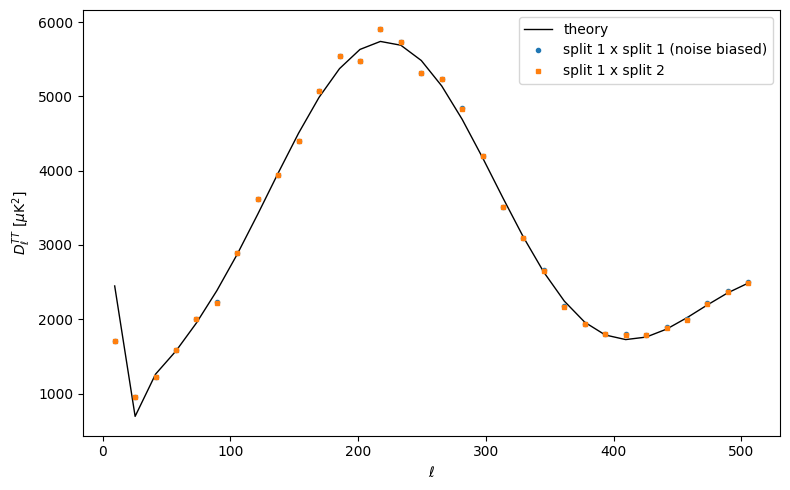

In [4]:
f1 = nmt.NmtField(mask, [split1], beam=beam)
f2 = nmt.NmtField(mask, [split2], beam=beam)
w = nmt.NmtWorkspace.from_fields(f1, f2, bins)          # same mask and beam: one workspace
auto = np.asarray(w.decouple_cell(nmt.compute_coupled_cell(f1, f1)))[0]
cross = np.asarray(w.decouple_cell(nmt.compute_coupled_cell(f1, f2)))[0]
theory = np.asarray(w.get_bandpower_windows())[0, :, 0, :] @ cl_tt

plt.figure(figsize=(8, 5))
plt.plot(ell_eff[keep], (fac * theory)[keep], "k-", lw=1, label="theory")
plt.plot(ell_eff[keep], (fac * auto)[keep], "o", ms=3, label="split 1 x split 1 (noise biased)")
plt.plot(ell_eff[keep], (fac * cross)[keep], "s", ms=3, label="split 1 x split 2")
plt.xlabel(r"$\ell$"); plt.ylabel(r"$D_\ell^{TT}$ [$\mu$K$^2$]"); plt.legend(); plt.tight_layout()

The beam is removed (the cross-spectrum follows the unbeamed theory out to $\ell \approx 500$,
where the beam suppresses the signal by a factor $b_\ell^2 \approx 0.5$). The noise bias of the auto-spectrum
rises as $b_\ell^{-2}$ at high $\ell$.

## Template deprojection

Suppose the map is contaminated by a foreground with a **known spatial template** $t(\hat n)$ but
unknown amplitude, e.g. a dust map. Passing `templates=[[t]]` to the field projects the template
out of the map before the power spectrum is computed. Removing a mode removes a little signal
too. `deprojection_bias` computes that small, known bias from a guess of the true spectrum, and
`decouple_cell(..., cl_bias=...)` subtracts it.

bias correction relative to the theory, first five bandpowers: [ 0.0236 -0.0203 -0.002  -0.0015 -0.0011]
largest above the second bandpower (ell < 2 nside): 2.0e-03


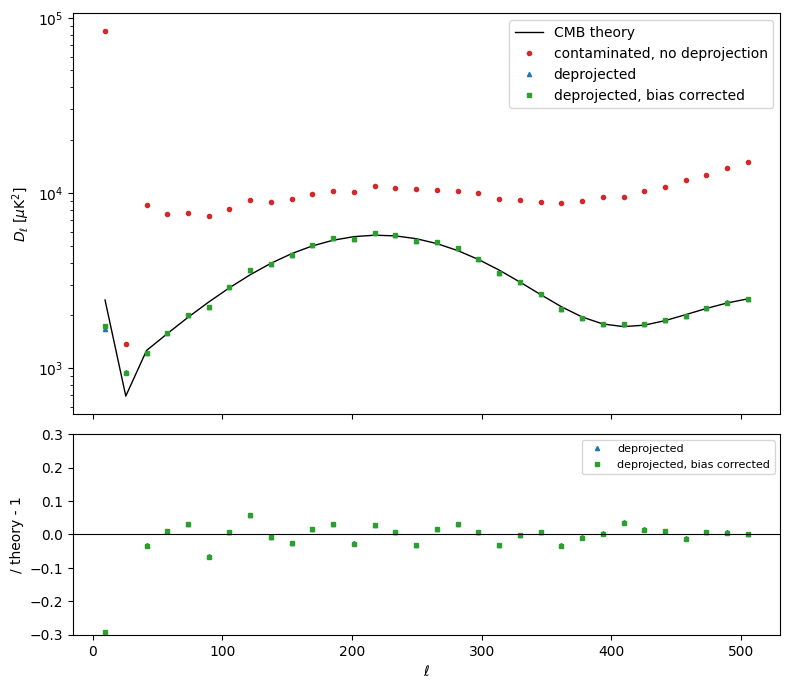

In [5]:
np.random.seed(11)
cl_fg = 5e4 * (ell + 1.0) ** -2.4                          # a red, dust-like spectrum
template = hp.synfast(cl_fg, nside, lmax=lmax, new=True)
contaminated = sky + 2.0 * template                        # amplitude unknown to the analysis

fields = {
    "contaminated, no deprojection": nmt.NmtField(mask, [contaminated], beam=beam),
    "deprojected": nmt.NmtField(mask, [contaminated], beam=beam, templates=[[template]]),
}
w_dp = nmt.NmtWorkspace.from_fields(fields["deprojected"], fields["deprojected"], bins)
results = {k: np.asarray(w_dp.decouple_cell(nmt.compute_coupled_cell(f, f)))[0] for k, f in fields.items()}

f = fields["deprojected"]
bias = nmt.deprojection_bias(f, f, [cl_tt * beam**2])      # guess: the (beamed) CMB spectrum
results["deprojected, bias corrected"] = np.asarray(
    w_dp.decouple_cell(nmt.compute_coupled_cell(f, f), cl_bias=bias))[0]

correction = (results["deprojected, bias corrected"] - results["deprojected"]) / theory
print("bias correction relative to the theory, first five bandpowers:", np.round(correction[:5], 4))
print(f"largest above the second bandpower (ell < 2 nside): {np.abs(correction[2:][keep[2:]]).max():.1e}")

style = {"contaminated, no deprojection": ("o", "C3"), "deprojected": ("^", "C0"),
         "deprojected, bias corrected": ("s", "C2")}
fig, (ax, axr) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax.semilogy(ell_eff[keep], (fac * theory)[keep], "k-", lw=1, label="CMB theory")
for k, v in results.items():
    marker, colour = style[k]
    ax.semilogy(ell_eff[keep], (fac * np.abs(v))[keep], marker, ms=3, color=colour, label=k)
    if k != "contaminated, no deprojection":
        axr.plot(ell_eff[keep], (v / theory - 1)[keep], marker, ms=3, color=colour, label=k)
axr.axhline(0, color="k", lw=0.8); axr.set_ylim(-0.3, 0.3)
ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]"); axr.set_ylabel("/ theory - 1"); axr.set_xlabel(r"$\ell$")
ax.legend(); axr.legend(fontsize=8); plt.tight_layout()

Deprojection removes the foreground completely. Removing one template also removes about one sky
mode, which biases the spectrum low by a known amount: here ~2% in the two lowest bandpowers and
at most 0.2% above, far below the cosmic variance of a single sky, so the corrected and uncorrected
points overlap. The correction matters when many templates are deprojected, or when many
simulations are averaged and cosmic variance no longer hides it. The remaining scatter is cosmic
variance.